# Environment Setup

In [1]:
pip install numpy pandas scipy scikit-learn matplotlib seaborn

# Importing Modules

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, f_regression

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve,
                              roc_auc_score, mean_absolute_error, mean_squared_error, r2_score)

 # Latex Formatting

In [3]:
plt.rcParams.update({
    'font.family': 'serif',   # generic serif, no external font install needed
    'font.size': 12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'savefig.dpi': 600,
})

def save_fig(fig, name, folder="figures"):
    """Save a matplotlib figure as .eps at 600 DPI for direct use in the LaTeX report."""
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved: {path}")
    return path

# Function I - Exploratory Data Analysis

In [4]:
def perform_eda(df, target_col=None, dataset_name="dataset", save_plots=True, max_plot_features=30):
    """
    Complete EDA: summary stats, missing values, outliers (IQR + Z-score),
    distributions, correlation heatmap, target distribution.
    """
    print("=" * 80)
    print(f"EXPLORATORY DATA ANALYSIS: {dataset_name}")
    print("=" * 80)

    print("\n--- Shape ---\n", df.shape)
    print("\n--- Data types ---\n", df.dtypes)
    print("\n--- Summary statistics ---\n", df.describe(include='all').T)

    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0]
    print("\n--- Missing Values ---")
    print(missing_df if not missing_df.empty else "No missing values found.")

    if missing_df.shape[0] > 0 and df.shape[1] <= max_plot_features:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax)
        ax.set_xlabel("Features", fontweight='bold')
        ax.set_ylabel("Samples", fontweight='bold')
        ax.set_title(f"Missing Value Heatmap - {dataset_name}")
        if save_plots: save_fig(fig, f"{dataset_name}_missing_heatmap")
        plt.show()

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    n = len(numeric_cols)
    high_dim = n > max_plot_features
    if high_dim:
        print(f"\n[Note] {n} numeric features detected — skipping per-feature histogram/boxplot/"
              f"correlation plots (only rendered when <= {max_plot_features} features) to keep "
              f"EDA readable and fast. Summary statistics above already cover all features.")

    # Distributions
    if n > 0 and not high_dim:
        ncols = min(n, 3)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = np.array(axes).reshape(-1)
        for i, col in enumerate(numeric_cols):
            axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='black')
            axes[i].set_xlabel(col, fontweight='bold')
            axes[i].set_ylabel("Frequency", fontweight='bold')
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        fig.suptitle(f"Distributions - {dataset_name}", fontweight='bold')
        plt.tight_layout()
        if save_plots: save_fig(fig, f"{dataset_name}_histograms")
        plt.show()

        # Boxplots
        fig, ax = plt.subplots(figsize=(max(8, n * 1.2), 5))
        df[numeric_cols].boxplot(ax=ax, rot=45)
        ax.set_xlabel("Features", fontweight='bold')
        ax.set_ylabel("Value", fontweight='bold')
        ax.set_title(f"Boxplots - {dataset_name}")
        if save_plots: save_fig(fig, f"{dataset_name}_boxplots")
        plt.show()

    # Outlier detection: IQR + Z-score (always computed, just not always plotted)
    outlier_summary = {}
    for col in numeric_cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        iqr_outliers = df[(df[col] < lb) | (df[col] > ub)].shape[0]
        z = np.abs(stats.zscore(df[col].dropna()))
        z_outliers = int((z > 3).sum())
        outlier_summary[col] = {'IQR_outliers': iqr_outliers, 'Zscore_outliers': z_outliers}
    outlier_df = pd.DataFrame(outlier_summary).T
    print("\n--- Outlier Summary (IQR & Z-score) ---\n", outlier_df if not high_dim else outlier_df.head(20))

    # Correlation heatmap
    if n > 1 and not high_dim:
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
        ax.set_xlabel("Features", fontweight='bold')
        ax.set_ylabel("Features", fontweight='bold')
        ax.set_title(f"Correlation Heatmap - {dataset_name}")
        if save_plots: save_fig(fig, f"{dataset_name}_correlation_heatmap")
        plt.show()

    # Target distribution
    if target_col and target_col in df.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        if df[target_col].dtype == 'object' or df[target_col].nunique() < 20:
            df[target_col].value_counts().plot(kind='bar', ax=ax, color='seagreen', edgecolor='black')
        else:
            ax.hist(df[target_col].dropna(), bins=20, color='seagreen', edgecolor='black')
        ax.set_xlabel(target_col, fontweight='bold')
        ax.set_ylabel("Count", fontweight='bold')
        ax.set_title(f"Target Distribution - {dataset_name}")
        if save_plots: save_fig(fig, f"{dataset_name}_target_distribution")
        plt.show()

    return {'missing': missing_df, 'outliers': outlier_df, 'describe': df.describe(include='all').T}

# Function II - All Classification Algorithms

In [5]:
def run_classification_models(X_train, y_train, X_test, y_test, dataset_name="dataset",
                                models=None, random_state=42):
    """
    Train multiple classifiers and evaluate each with classification_metrics().
    Returns {model_name: {'model', 'y_pred', 'y_proba', 'metrics'}}
    """
    if models is None:
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
            "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
            "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=random_state),
            "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=random_state),
            "Decision Tree": DecisionTreeClassifier(random_state=random_state),
            "Random Forest": RandomForestClassifier(n_estimators=200, random_state=random_state),
            "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),
            "Naive Bayes": GaussianNB(),
        }

    results = {}
    for name, model in models.items():
        print(f"\nTraining: {name} ...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
        metrics = classification_metrics(y_test, y_pred, y_proba, model_name=name,
                                          dataset_name=dataset_name, plot=False)
        results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba, 'metrics': metrics}
    return results

# Function III - All Classification Performance Metrics

In [6]:
def classification_metrics(y_true, y_pred, y_proba=None, model_name="Model", average='weighted',
                            dataset_name="dataset", plot=True, save_plots=True):
    """
    Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix, Classification Report.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

    n_classes = len(np.unique(y_true))
    roc_auc_val = None
    if y_proba is not None:
        try:
            roc_auc_val = (roc_auc_score(y_true, y_proba[:, 1]) if n_classes == 2
                            else roc_auc_score(y_true, y_proba, multi_class='ovr', average=average))
            metrics['ROC-AUC'] = roc_auc_val
        except Exception:
            pass

    print(f"\n--- Classification Metrics: {model_name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    if plot:
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_xlabel("Predicted Label", fontweight='bold')
        ax.set_ylabel("True Label", fontweight='bold')
        ax.set_title(f"Confusion Matrix - {model_name}")
        if save_plots: save_fig(fig, f"{dataset_name}_{model_name.replace(' ', '_')}_cm")
        plt.show()

        if y_proba is not None and n_classes == 2:
            fpr, tpr, _ = roc_curve(y_true, y_proba[:, 1])
            fig, ax = plt.subplots(figsize=(5, 4))
            ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_val:.3f}")
            ax.plot([0, 1], [0, 1], '--', color='gray')
            ax.set_xlabel("False Positive Rate", fontweight='bold')
            ax.set_ylabel("True Positive Rate", fontweight='bold')
            ax.set_title(f"ROC Curve - {model_name}")
            ax.legend()
            if save_plots: save_fig(fig, f"{dataset_name}_{model_name.replace(' ', '_')}_roc")
            plt.show()

    metrics['Confusion Matrix'] = cm
    return metrics

# Function IV - All Regression Performance Metrics

In [7]:
def regression_metrics(y_true, y_pred, n_features=None, model_name="Model", dataset_name="dataset",
                        plot=True, save_plots=True):
    """
    MAE, MSE, RMSE, R2, Adjusted R2, MAPE + Actual-vs-Predicted and Residual plots.
    """
    y_true_arr, y_pred_arr = np.array(y_true), np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true_arr - y_pred_arr) / np.where(y_true_arr == 0, 1e-9, y_true_arr))) * 100

    metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2, 'MAPE (%)': mape}

    if n_features is not None:
        n = len(y_true)
        metrics['Adjusted R2'] = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    print(f"\n--- Regression Metrics: {model_name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
        lims = [min(y_true_arr.min(), y_pred_arr.min()), max(y_true_arr.max(), y_pred_arr.max())]
        ax.plot(lims, lims, '--', color='red')
        ax.set_xlabel("Actual Values", fontweight='bold')
        ax.set_ylabel("Predicted Values", fontweight='bold')
        ax.set_title(f"Actual vs Predicted - {model_name}")
        if save_plots: save_fig(fig, f"{dataset_name}_{model_name.replace(' ', '_')}_actual_vs_pred")
        plt.show()

        residuals = y_true_arr - y_pred_arr
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(y_pred, residuals, alpha=0.6, edgecolor='k')
        ax.axhline(0, color='red', linestyle='--')
        ax.set_xlabel("Predicted Values", fontweight='bold')
        ax.set_ylabel("Residuals", fontweight='bold')
        ax.set_title(f"Residual Plot - {model_name}")
        if save_plots: save_fig(fig, f"{dataset_name}_{model_name.replace(' ', '_')}_residuals")
        plt.show()

    return metrics

# Full End-to-End ML Pipeline

In [8]:
def run_ml_pipeline(df, target_col, task_type='classification', dataset_name="dataset",
                     test_size=0.2, k_best=None, scale_method='standard', random_state=42):
    """
    EDA -> Preprocess (impute, encode, scale) -> Feature Select -> Split -> Train -> Evaluate -> Summarize.
    task_type: 'classification' or 'regression'
    """
    df = df.copy()

    # Step 1: EDA
    eda_results = perform_eda(df, target_col=target_col, dataset_name=dataset_name)

    # Step 2: Preprocessing
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    for col_list in (num_cols, cat_cols):
        if target_col in col_list:
            col_list.remove(target_col)

    if num_cols:
        df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])
    if cat_cols:
        df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    if task_type == 'classification' and df[target_col].dtype == 'object':
        df[target_col] = LabelEncoder().fit_transform(df[target_col].astype(str))

    X = df.drop(columns=[target_col])
    y = df[target_col]

    scaler = StandardScaler() if scale_method == 'standard' else MinMaxScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    # Step 3: Feature Selection
    if k_best and k_best < X_scaled.shape[1]:
        score_func = f_classif if task_type == 'classification' else f_regression
        selector = SelectKBest(score_func=score_func, k=k_best)
        X_sel = selector.fit_transform(X_scaled, y)
        selected_cols = X.columns[selector.get_support()]
        X_scaled = pd.DataFrame(X_sel, columns=selected_cols)
        print(f"\nSelected top {k_best} features: {list(selected_cols)}")

    # Step 4: Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=random_state,
        stratify=y if task_type == 'classification' else None)

    # Step 5: Train + Evaluate
    all_metrics = {}
    if task_type == 'classification':
        results = run_classification_models(X_train, y_train, X_test, y_test, dataset_name=dataset_name)
        for name, r in results.items():
            all_metrics[name] = r['metrics']
    else:
        models = {
            "Linear Regression": LinearRegression(),
            "Ridge Regression": Ridge(),
            "Lasso Regression": Lasso(),
            "Decision Tree Regressor": DecisionTreeRegressor(random_state=random_state),
            "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=random_state),
            "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=random_state),
            "SVR": SVR(),
        }
        for name, model in models.items():
            print(f"\nTraining: {name} ...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            all_metrics[name] = regression_metrics(y_test, y_pred, n_features=X_train.shape[1],
                                                     model_name=name, dataset_name=dataset_name)

    # Step 6: Summary
    summary_df = pd.DataFrame(all_metrics).T.drop(columns=['Confusion Matrix'], errors='ignore')
    print("\n" + "=" * 80)
    print(f"SUMMARY - {dataset_name} ({task_type})")
    print("=" * 80)
    print(summary_df)

    return {'eda': eda_results, 'summary': summary_df, 'metrics': all_metrics}

# Image Loader

In [9]:
from PIL import Image

def load_image_dataset(csv_path, img_root, image_col='image', label_col='label',
                        img_size=(32, 32), grayscale=True):
    """
    Converts an image-path + label CSV (e.g. english.csv for the handwritten
    character recognition dataset) into a flat pixel-feature DataFrame that
    run_ml_pipeline() can consume directly.
    """
    df_meta = pd.read_csv(csv_path)
    features = []
    for rel_path in df_meta[image_col]:
        img = Image.open(os.path.join(img_root, rel_path))
        img = img.convert('L') if grayscale else img.convert('RGB')
        img = img.resize(img_size)
        features.append(np.asarray(img, dtype=np.float32).flatten())

    feat_cols = [f'pixel_{i}' for i in range(len(features[0]))]
    img_df = pd.DataFrame(features, columns=feat_cols)
    img_df[label_col] = df_meta[label_col].astype(str).values
    return img_df

# Dataset to be Trained

In [13]:
from google.colab import files

uploaded = files.upload()
# Select: iris_dataset.zip, diabetes_prediction.zip, loan_amount_prediction.zip,
#         email_classification.zip, handwritten_character_recognition.zip

Saving diabetes_prediction.zip to diabetes_prediction.zip
Saving email_classification.zip to email_classification.zip
Saving handwritten_character_recognition.zip to handwritten_character_recognition.zip
Saving iris_dataset.zip to iris_dataset.zip
Saving loan_amount_prediction.zip to loan_amount_prediction.zip


In [14]:
import zipfile, os

zip_files = [
    'iris_dataset.zip',
    'diabetes_prediction.zip',
    'loan_amount_prediction.zip',
    'email_classification.zip',
    'handwritten_character_recognition.zip',
]

for zf in zip_files:
    folder_name = zf.replace('.zip', '')
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(folder_name)
    print(f"Extracted {zf} -> {folder_name}/")

Extracted iris_dataset.zip -> iris_dataset/
Extracted diabetes_prediction.zip -> diabetes_prediction/
Extracted loan_amount_prediction.zip -> loan_amount_prediction/
Extracted email_classification.zip -> email_classification/
Extracted handwritten_character_recognition.zip -> handwritten_character_recognition/


## Iris - classification

EXPLORATORY DATA ANALYSIS: Iris

--- Shape ---
 (150, 5)

--- Data types ---
 SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

--- Summary statistics ---
                count unique          top freq      mean       std  min  25%  \
SepalLengthCm  150.0    NaN          NaN  NaN  5.843333  0.828066  4.3  5.1   
SepalWidthCm   150.0    NaN          NaN  NaN     3.054  0.433594  2.0  2.8   
PetalLengthCm  150.0    NaN          NaN  NaN  3.758667   1.76442  1.0  1.6   
PetalWidthCm   150.0    NaN          NaN  NaN  1.198667  0.763161  0.1  0.3   
Species          150      3  Iris-setosa   50       NaN       NaN  NaN  NaN   

                50%  75%  max  
SepalLengthCm   5.8  6.4  7.9  
SepalWidthCm    3.0  3.3  4.4  
PetalLengthCm  4.35  5.1  6.9  
PetalWidthCm    1.3  1.8  2.5  
Species         NaN  NaN  NaN  

--- Missing Values ---
No missing values found.
Saved: figures/Iris_histograms.eps


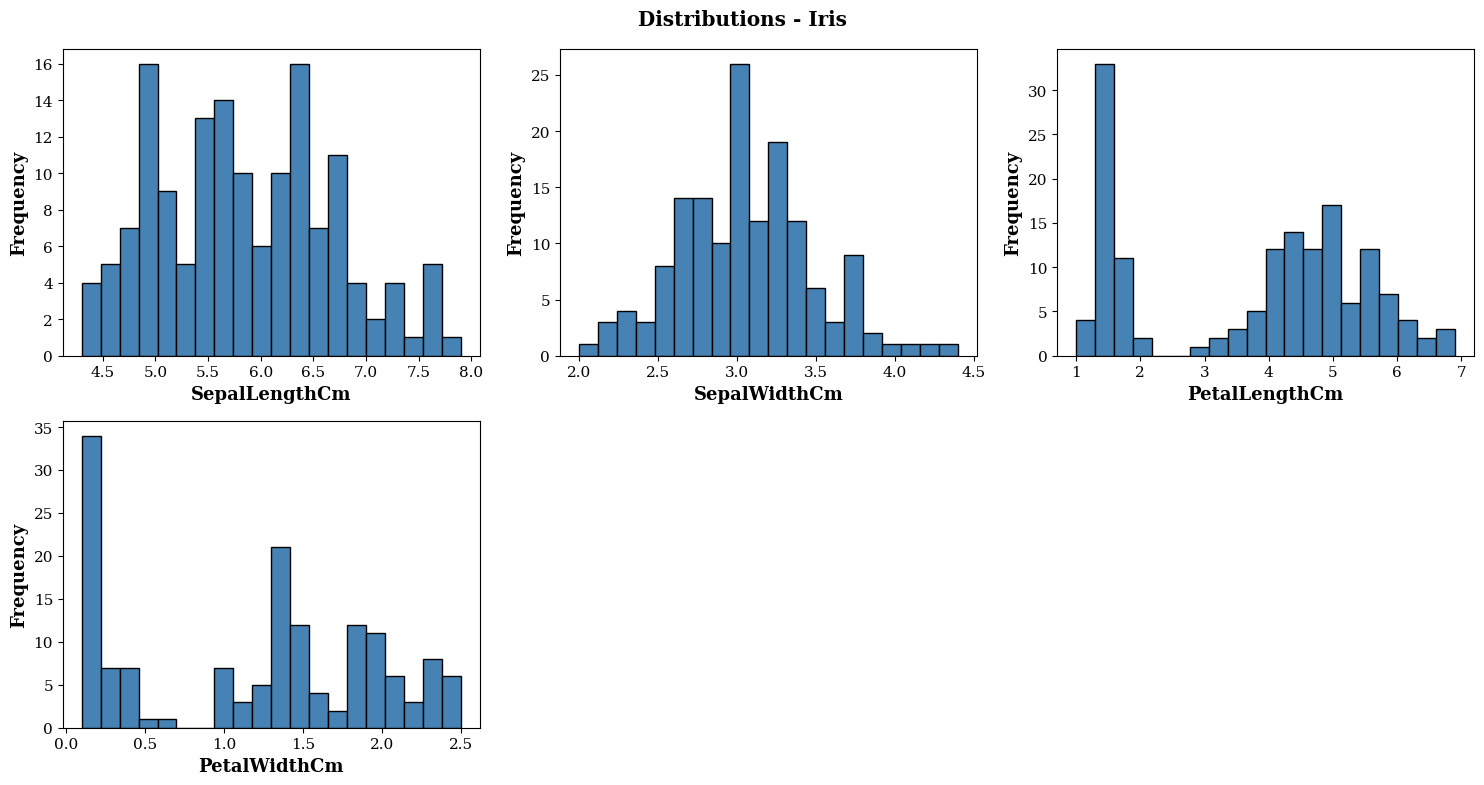

Saved: figures/Iris_boxplots.eps


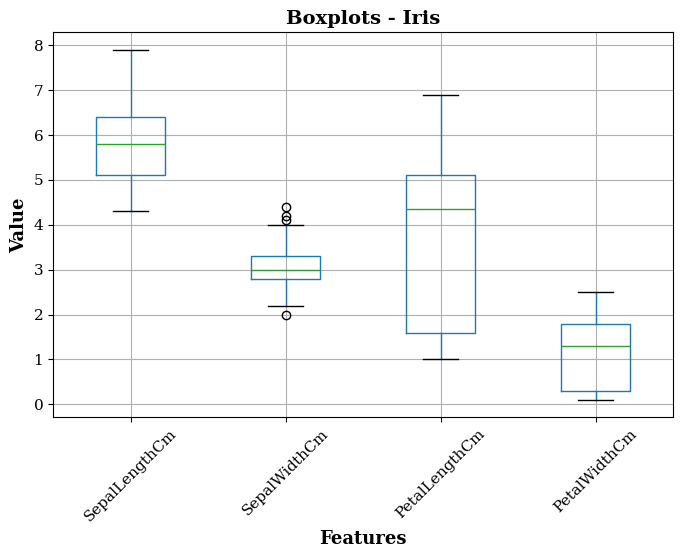


--- Outlier Summary (IQR & Z-score) ---
                IQR_outliers  Zscore_outliers
SepalLengthCm             0                0
SepalWidthCm              4                1
PetalLengthCm             0                0
PetalWidthCm              0                0
Saved: figures/Iris_correlation_heatmap.eps


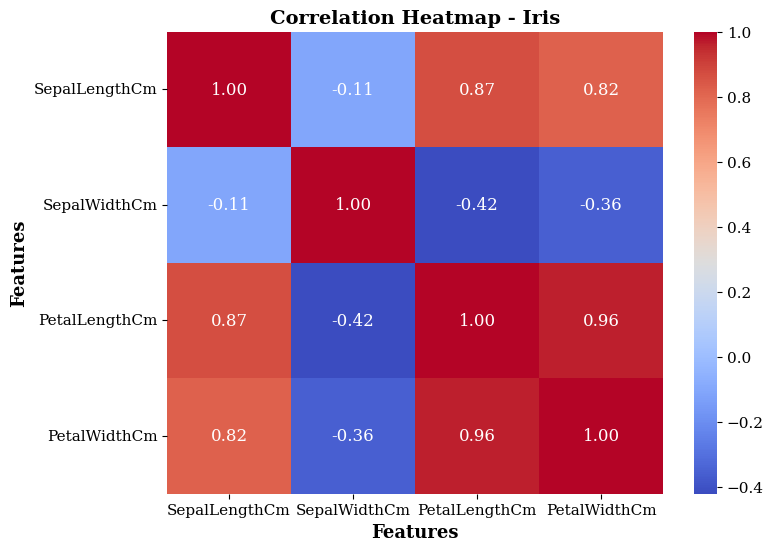

Saved: figures/Iris_target_distribution.eps


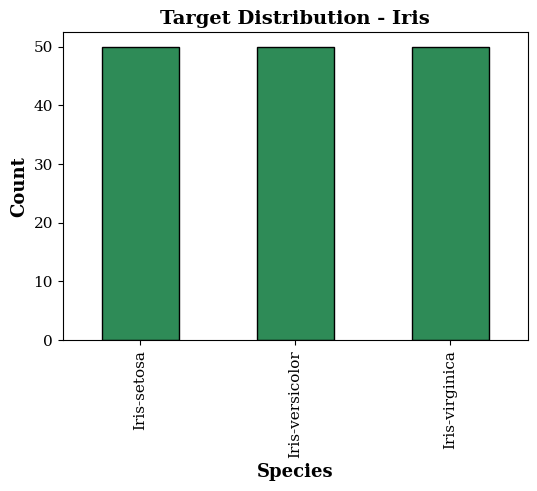


Training: Logistic Regression ...

--- Classification Metrics: Logistic Regression ---
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1-Score: 0.9333
ROC-AUC: 0.9967

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Training: K-Nearest Neighbors ...

--- Classification Metrics: K-Nearest Neighbors ---
Accuracy: 0.9333
Precision: 0.9444
Recall: 0.9333
F1-Score: 0.9327
ROC-AUC: 0.9933

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accur

{'eda': {'missing': Empty DataFrame
  Columns: [Missing Count, Missing %]
  Index: [],
  'outliers':                IQR_outliers  Zscore_outliers
  SepalLengthCm             0                0
  SepalWidthCm              4                1
  PetalLengthCm             0                0
  PetalWidthCm              0                0,
  'describe':                count unique          top freq      mean       std  min  25%  \
  SepalLengthCm  150.0    NaN          NaN  NaN  5.843333  0.828066  4.3  5.1   
  SepalWidthCm   150.0    NaN          NaN  NaN     3.054  0.433594  2.0  2.8   
  PetalLengthCm  150.0    NaN          NaN  NaN  3.758667   1.76442  1.0  1.6   
  PetalWidthCm   150.0    NaN          NaN  NaN  1.198667  0.763161  0.1  0.3   
  Species          150      3  Iris-setosa   50       NaN       NaN  NaN  NaN   
  
                  50%  75%  max  
  SepalLengthCm   5.8  6.4  7.9  
  SepalWidthCm    3.0  3.3  4.4  
  PetalLengthCm  4.35  5.1  6.9  
  PetalWidthCm    1.3  1.8  

In [16]:
# Iris - classification
iris = pd.read_csv('iris_dataset/Iris.csv').drop(columns=['Id'])
run_ml_pipeline(iris, target_col='Species', task_type='classification', dataset_name='Iris')

## Digits (handwritten characters) - classification

EXPLORATORY DATA ANALYSIS: Handwritten_Char

--- Shape ---
 (3410, 1025)

--- Data types ---
 pixel_0       float32
pixel_1       float32
pixel_2       float32
pixel_3       float32
pixel_4       float32
               ...   
pixel_1020    float32
pixel_1021    float32
pixel_1022    float32
pixel_1023    float32
label          object
Length: 1025, dtype: object

--- Summary statistics ---
              count unique  top freq   mean  std    min    25%    50%    75%  \
pixel_0     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
pixel_1     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
pixel_2     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
pixel_3     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
pixel_4     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
...            ...    ...  ...  ...    ...  ...    ...    ...    ...    ...   
pixel_1020  3410.0    NaN  NaN  NaN  255.0  0.0  255.0

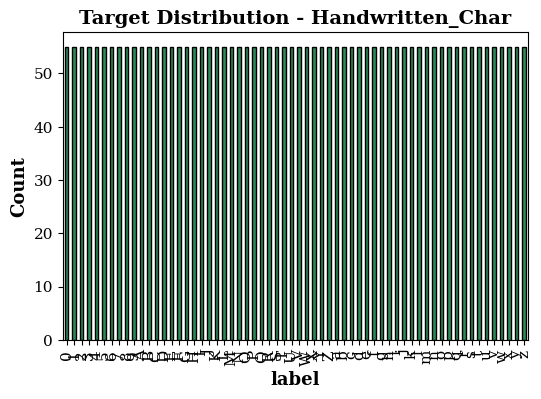


Selected top 100 features: ['pixel_238', 'pixel_239', 'pixel_240', 'pixel_241', 'pixel_242', 'pixel_243', 'pixel_244', 'pixel_267', 'pixel_268', 'pixel_269', 'pixel_270', 'pixel_271', 'pixel_272', 'pixel_273', 'pixel_274', 'pixel_275', 'pixel_276', 'pixel_299', 'pixel_300', 'pixel_301', 'pixel_302', 'pixel_303', 'pixel_304', 'pixel_305', 'pixel_306', 'pixel_307', 'pixel_308', 'pixel_331', 'pixel_332', 'pixel_333', 'pixel_334', 'pixel_335', 'pixel_336', 'pixel_337', 'pixel_338', 'pixel_339', 'pixel_340', 'pixel_362', 'pixel_363', 'pixel_364', 'pixel_365', 'pixel_368', 'pixel_369', 'pixel_370', 'pixel_371', 'pixel_372', 'pixel_394', 'pixel_395', 'pixel_396', 'pixel_400', 'pixel_401', 'pixel_402', 'pixel_403', 'pixel_404', 'pixel_426', 'pixel_431', 'pixel_432', 'pixel_433', 'pixel_434', 'pixel_435', 'pixel_436', 'pixel_458', 'pixel_463', 'pixel_464', 'pixel_465', 'pixel_466', 'pixel_467', 'pixel_468', 'pixel_490', 'pixel_491', 'pixel_495', 'pixel_496', 'pixel_497', 'pixel_498', 'pixel_49

{'eda': {'missing': Empty DataFrame
  Columns: [Missing Count, Missing %]
  Index: [],
  'outliers':             IQR_outliers  Zscore_outliers
  pixel_0                0                0
  pixel_1                0                0
  pixel_2                0                0
  pixel_3                0                0
  pixel_4                0                0
  ...                  ...              ...
  pixel_1019             0                0
  pixel_1020             0                0
  pixel_1021             0                0
  pixel_1022             0                0
  pixel_1023             0                0
  
  [1024 rows x 2 columns],
  'describe':              count unique  top freq   mean  std    min    25%    50%    75%  \
  pixel_0     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
  pixel_1     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
  pixel_2     3410.0    NaN  NaN  NaN  255.0  0.0  255.0  255.0  255.0  255.0   
  pixel

In [17]:
# Handwritten Character Recognition - classification (62 classes: 0-9, A-Z, a-z)
digits = load_image_dataset(
    csv_path='handwritten_character_recognition/english.csv',
    img_root='handwritten_character_recognition',
    img_size=(32, 32)
)
run_ml_pipeline(digits, target_col='label', task_type='classification',
                 dataset_name='Handwritten_Char', k_best=100)

## Diabetes - classification

EXPLORATORY DATA ANALYSIS: Diabetes

--- Shape ---
 (768, 9)

--- Data types ---
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

--- Summary statistics ---
                           count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedi

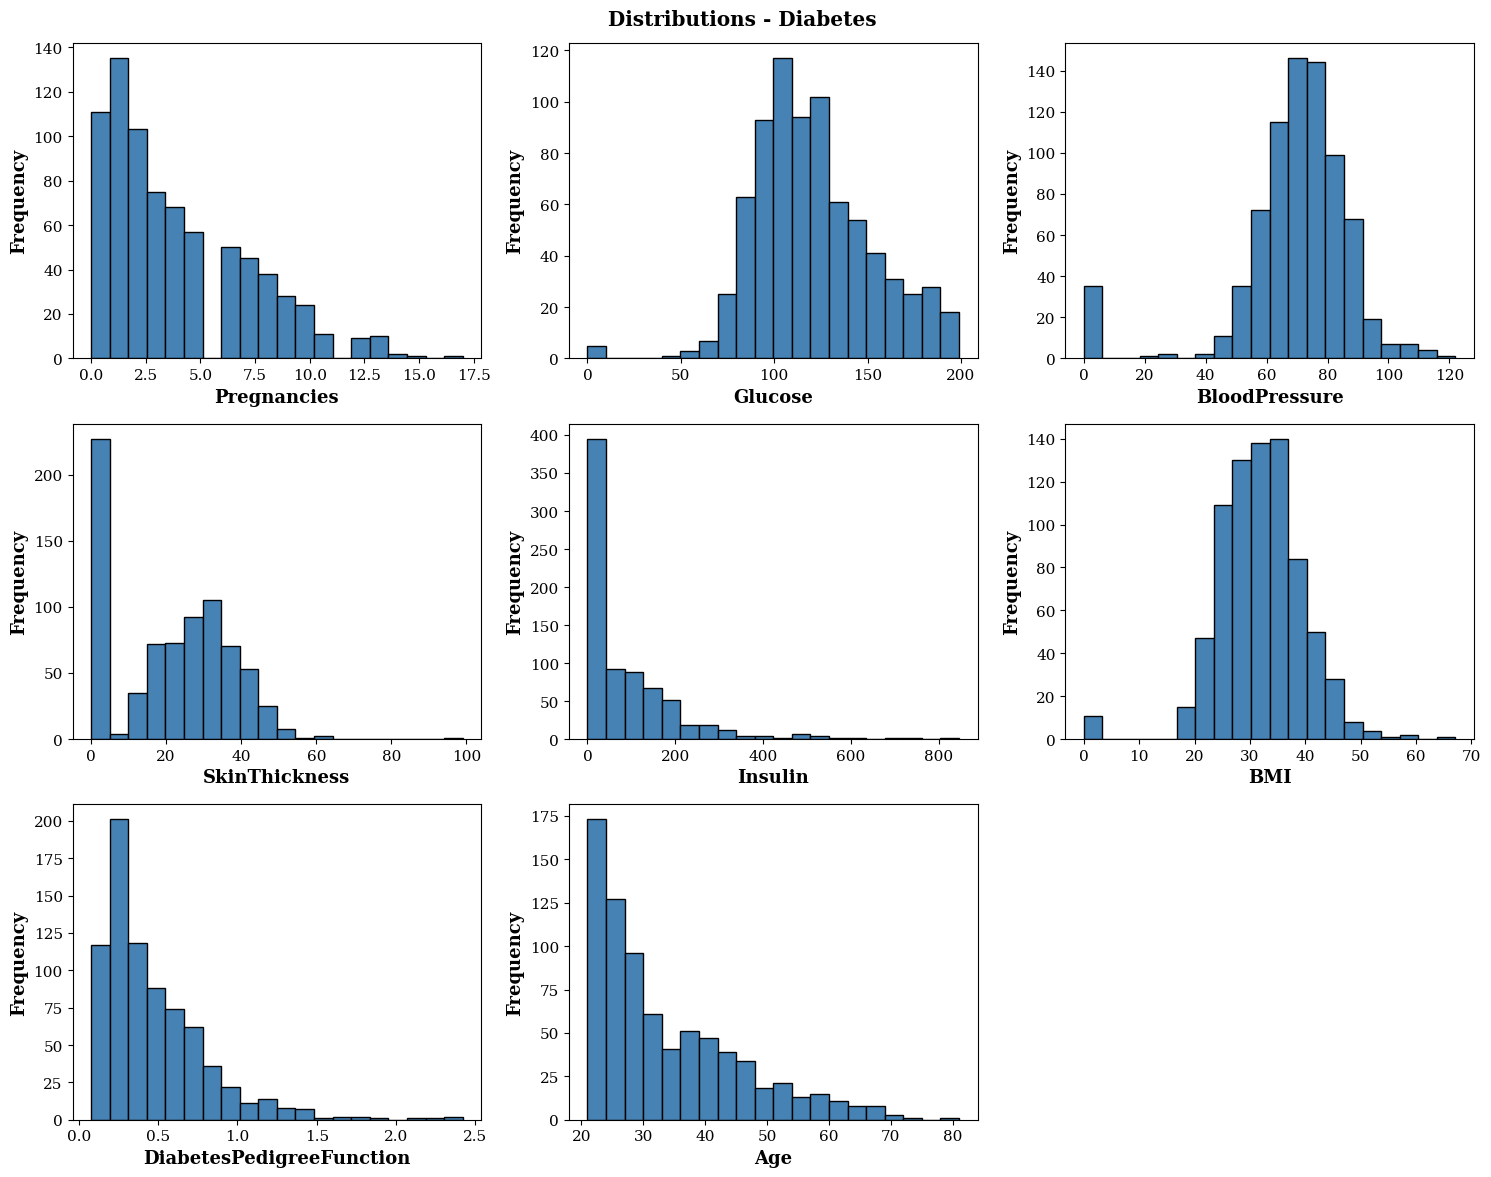

Saved: figures/Diabetes_boxplots.eps


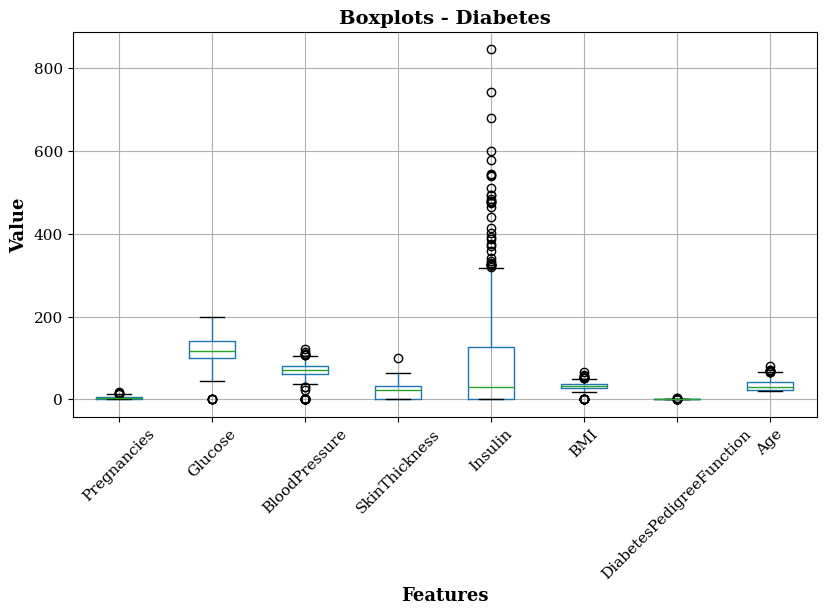


--- Outlier Summary (IQR & Z-score) ---
                           IQR_outliers  Zscore_outliers
Pregnancies                          4                4
Glucose                              5                5
BloodPressure                       45               35
SkinThickness                        1                1
Insulin                             34               18
BMI                                 19               14
DiabetesPedigreeFunction            29               11
Age                                  9                5
Saved: figures/Diabetes_correlation_heatmap.eps


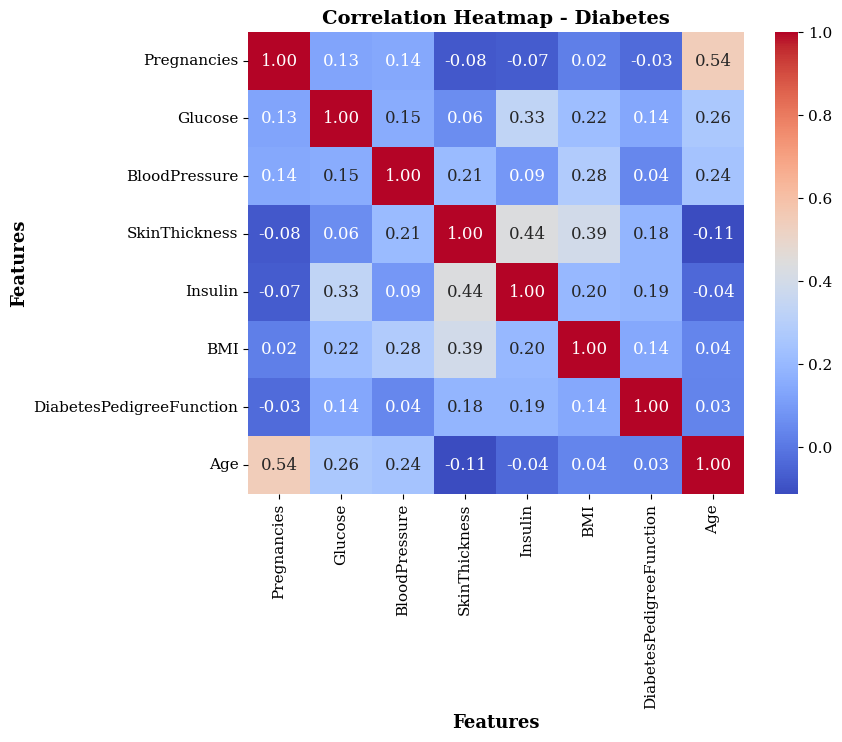

Saved: figures/Diabetes_target_distribution.eps


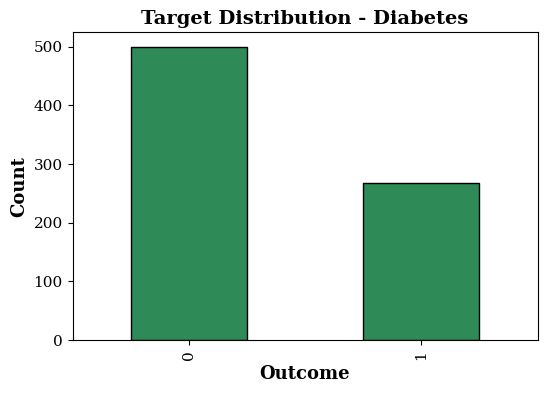


Training: Logistic Regression ...

--- Classification Metrics: Logistic Regression ---
Accuracy: 0.7143
Precision: 0.7065
Recall: 0.7143
F1-Score: 0.7084
ROC-AUC: 0.8230

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Training: K-Nearest Neighbors ...

--- Classification Metrics: K-Nearest Neighbors ---
Accuracy: 0.7078
Precision: 0.7023
Recall: 0.7078
F1-Score: 0.7043
ROC-AUC: 0.7458

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78       100
           1       0.59      0.54      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted 

{'eda': {'missing': Empty DataFrame
  Columns: [Missing Count, Missing %]
  Index: [],
  'outliers':                           IQR_outliers  Zscore_outliers
  Pregnancies                          4                4
  Glucose                              5                5
  BloodPressure                       45               35
  SkinThickness                        1                1
  Insulin                             34               18
  BMI                                 19               14
  DiabetesPedigreeFunction            29               11
  Age                                  9                5,
  'describe':                           count        mean         std     min       25%  \
  Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
  Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
  BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
  SkinThickness             768.0   20.536458   15

In [18]:
# Diabetes - classification
df_diabetes = pd.read_csv('diabetes_prediction/diabetes.csv')
run_ml_pipeline(df_diabetes, target_col='Outcome', task_type='classification', dataset_name='Diabetes')

## Loan Approval Prediction - classification

EXPLORATORY DATA ANALYSIS: Loan_Amount

--- Shape ---
 (592, 12)

--- Data types ---
 Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

--- Summary statistics ---
                    count unique        top freq         mean          std  \
Gender               579      2       Male  470          NaN          NaN   
Married              590      2        Yes  384          NaN          NaN   
Dependents           579      4          0  334          NaN          NaN   
Education            592      2   Graduate  465          NaN          NaN   
Self_Employed        561      2         No  482          NaN          NaN   
ApplicantIncome    592.0    NaN        NaN  NaN  5404.304054 

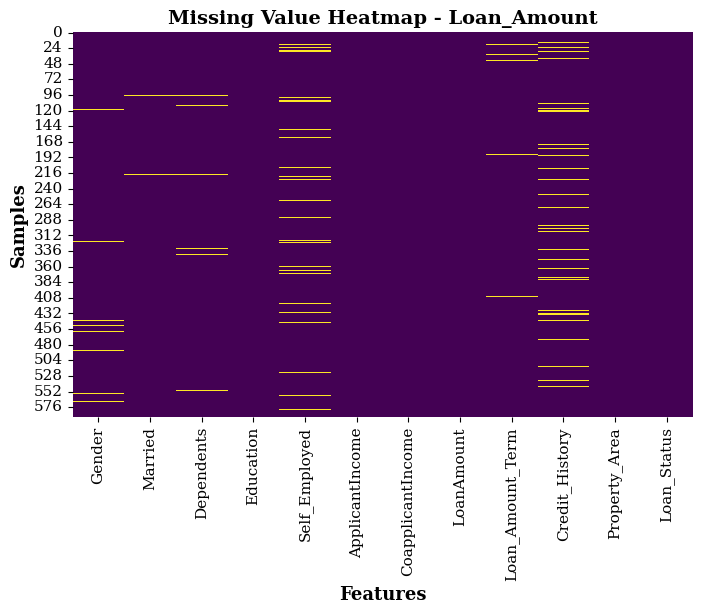

Saved: figures/Loan_Amount_histograms.eps


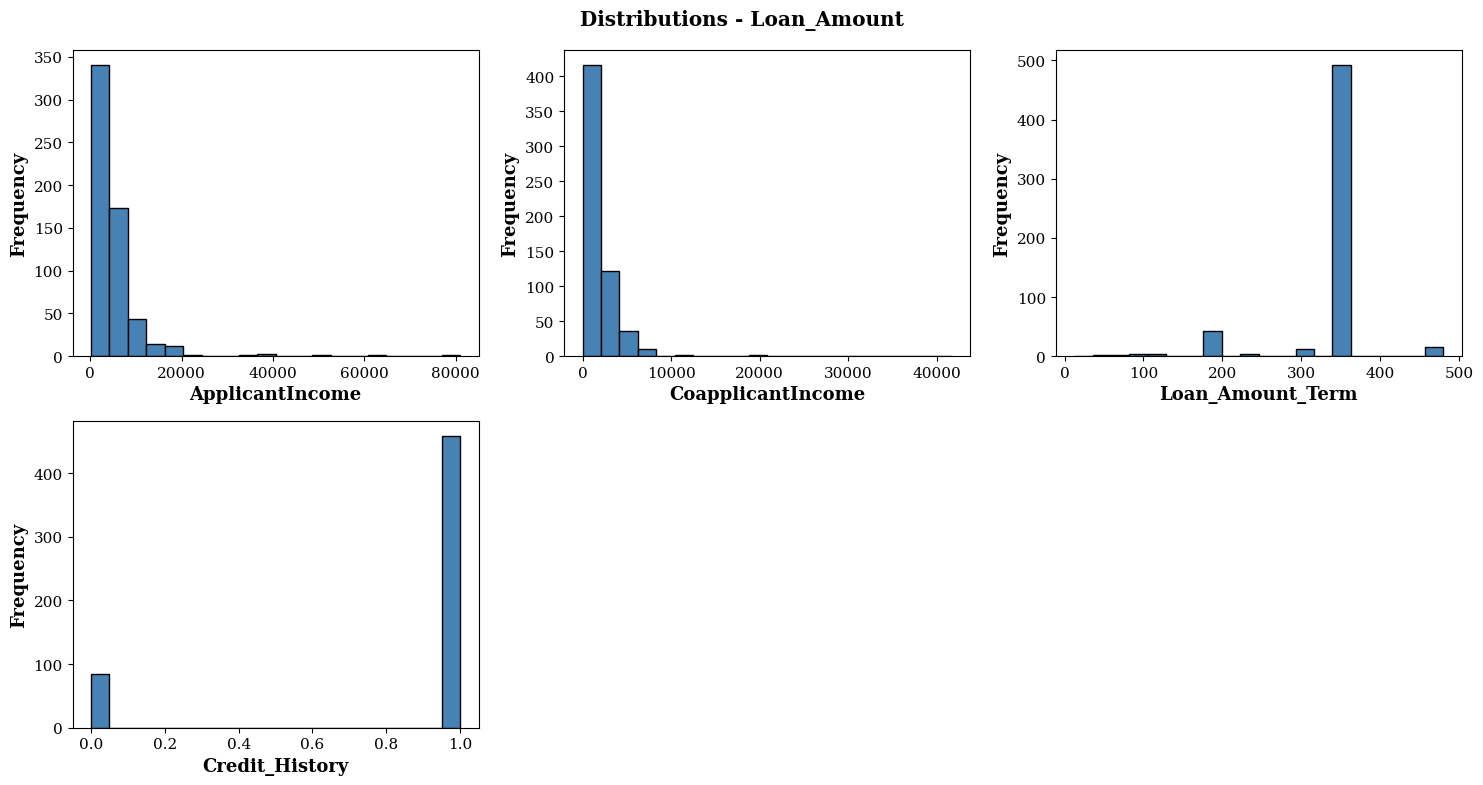

Saved: figures/Loan_Amount_boxplots.eps


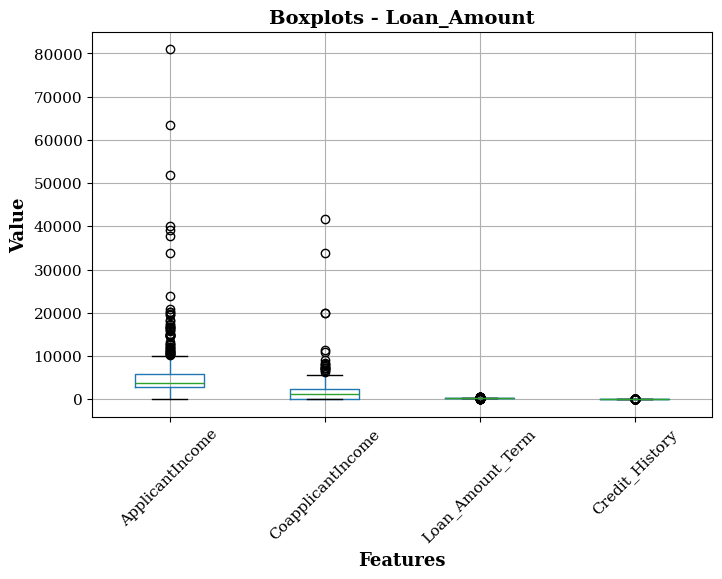


--- Outlier Summary (IQR & Z-score) ---
                    IQR_outliers  Zscore_outliers
ApplicantIncome              49                7
CoapplicantIncome            18                6
Loan_Amount_Term             85               12
Credit_History               85                0
Saved: figures/Loan_Amount_correlation_heatmap.eps


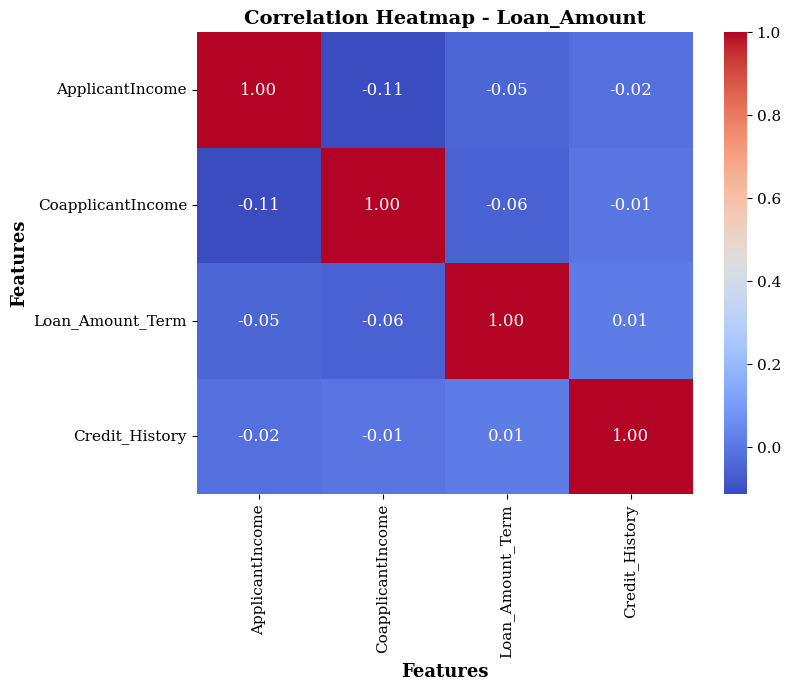

Saved: figures/Loan_Amount_target_distribution.eps


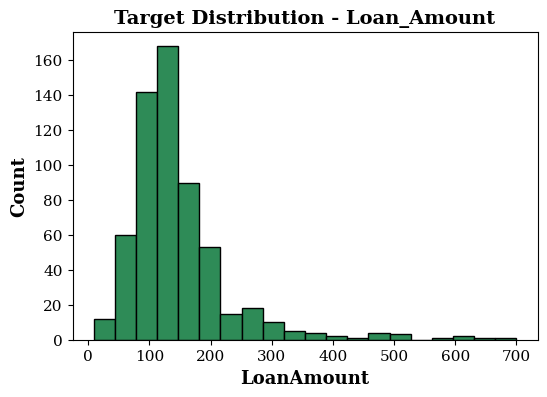


Training: Linear Regression ...

--- Regression Metrics: Linear Regression ---
MAE: 36.6989
MSE: 3324.8175
RMSE: 57.6612
R2 Score: 0.0981
MAPE (%): 35.4658
Adjusted R2: 0.0054
Saved: figures/Loan_Amount_Linear_Regression_actual_vs_pred.eps


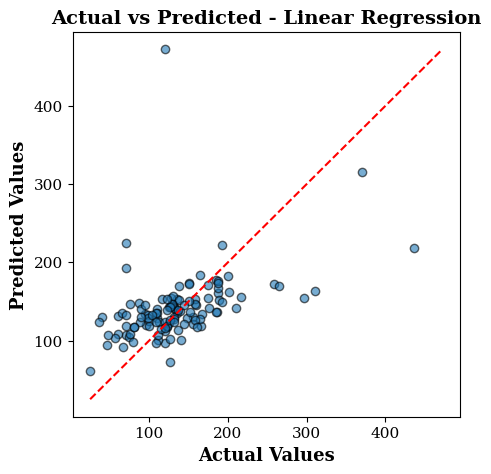

Saved: figures/Loan_Amount_Linear_Regression_residuals.eps


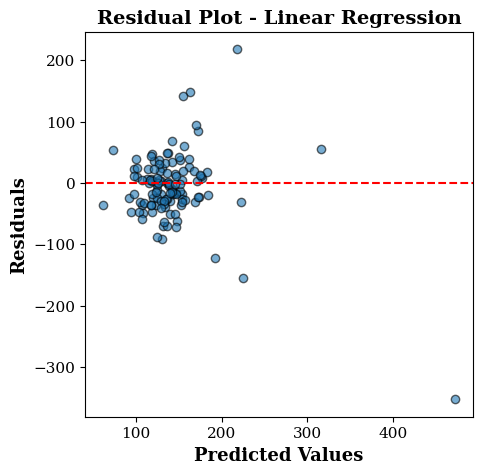


Training: Ridge Regression ...

--- Regression Metrics: Ridge Regression ---
MAE: 36.7015
MSE: 3322.1388
RMSE: 57.6380
R2 Score: 0.0988
MAPE (%): 35.4790
Adjusted R2: 0.0062
Saved: figures/Loan_Amount_Ridge_Regression_actual_vs_pred.eps


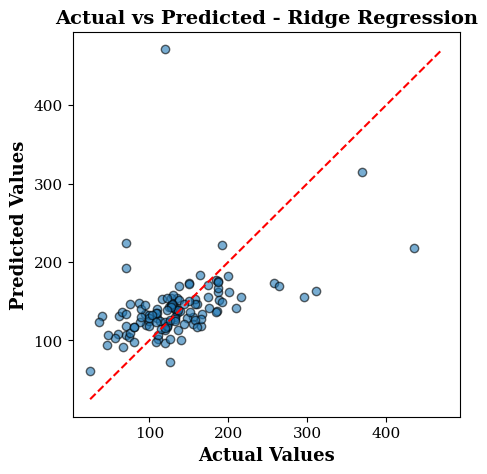

Saved: figures/Loan_Amount_Ridge_Regression_residuals.eps


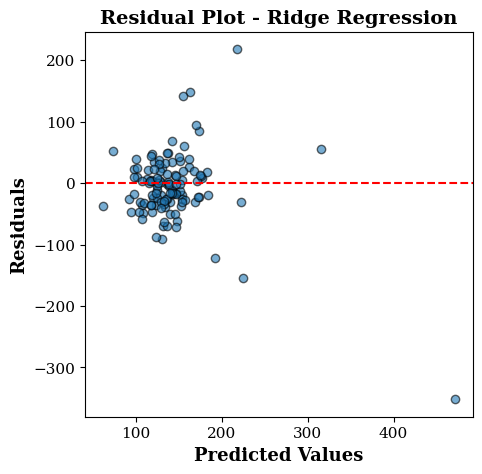


Training: Lasso Regression ...

--- Regression Metrics: Lasso Regression ---
MAE: 36.1555
MSE: 3273.6524
RMSE: 57.2158
R2 Score: 0.1120
MAPE (%): 35.3014
Adjusted R2: 0.0207
Saved: figures/Loan_Amount_Lasso_Regression_actual_vs_pred.eps


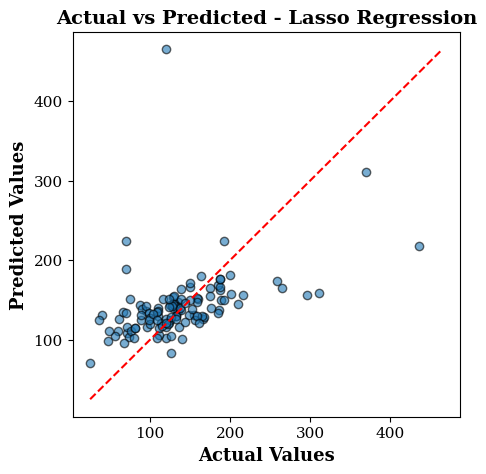

Saved: figures/Loan_Amount_Lasso_Regression_residuals.eps


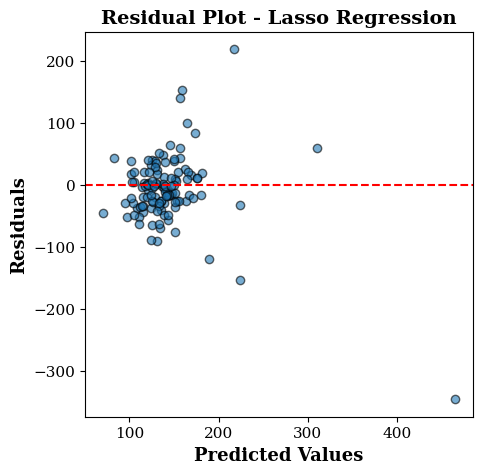


Training: Decision Tree Regressor ...

--- Regression Metrics: Decision Tree Regressor ---
MAE: 48.9832
MSE: 5382.0924
RMSE: 73.3627
R2 Score: -0.4600
MAPE (%): 42.2095
Adjusted R2: -0.6101
Saved: figures/Loan_Amount_Decision_Tree_Regressor_actual_vs_pred.eps


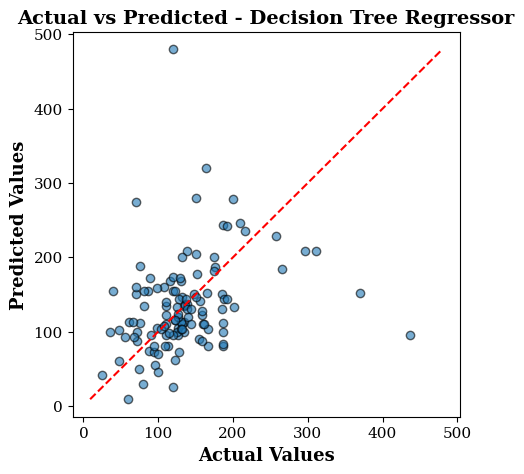

Saved: figures/Loan_Amount_Decision_Tree_Regressor_residuals.eps


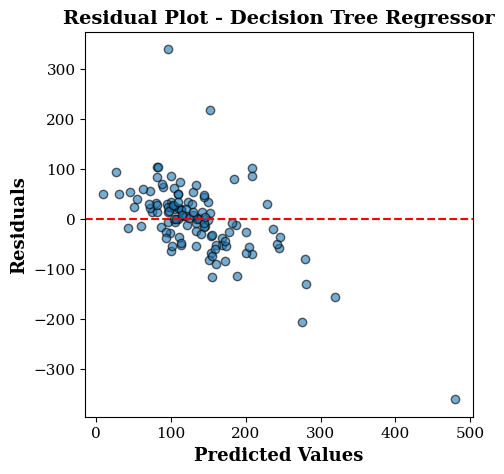


Training: Random Forest Regressor ...



--- Regression Metrics: Random Forest Regressor ---
MAE: 33.9438
MSE: 3132.6796
RMSE: 55.9703
R2 Score: 0.1502
MAPE (%): 30.5887
Adjusted R2: 0.0628
Saved: figures/Loan_Amount_Random_Forest_Regressor_actual_vs_pred.eps


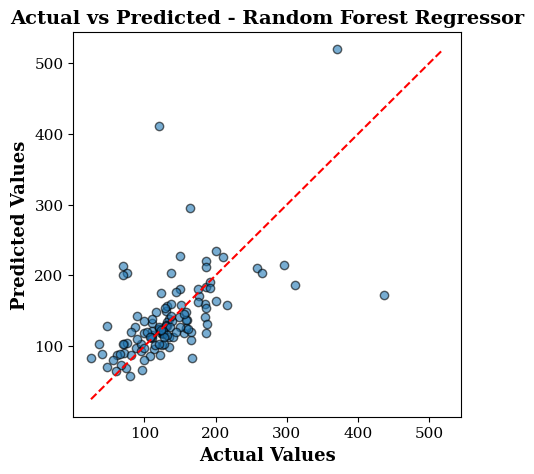

Saved: figures/Loan_Amount_Random_Forest_Regressor_residuals.eps


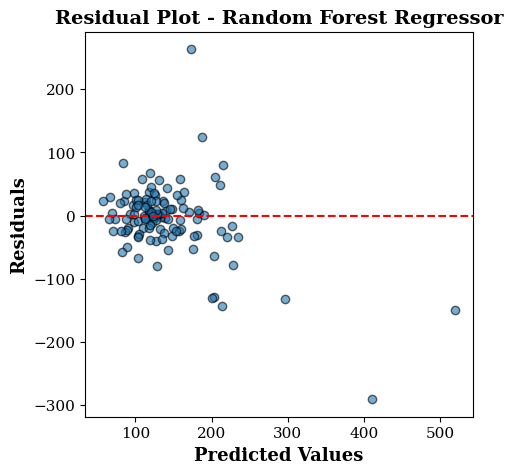


Training: Gradient Boosting Regressor ...

--- Regression Metrics: Gradient Boosting Regressor ---
MAE: 33.4631
MSE: 2897.2455
RMSE: 53.8261
R2 Score: 0.2141
MAPE (%): 29.7789
Adjusted R2: 0.1333


Saved: figures/Loan_Amount_Gradient_Boosting_Regressor_actual_vs_pred.eps


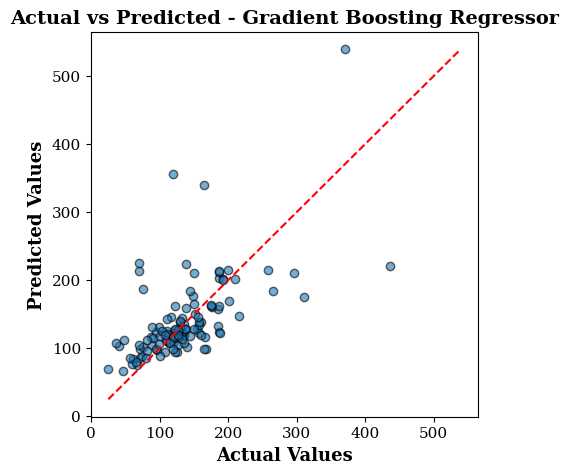

Saved: figures/Loan_Amount_Gradient_Boosting_Regressor_residuals.eps


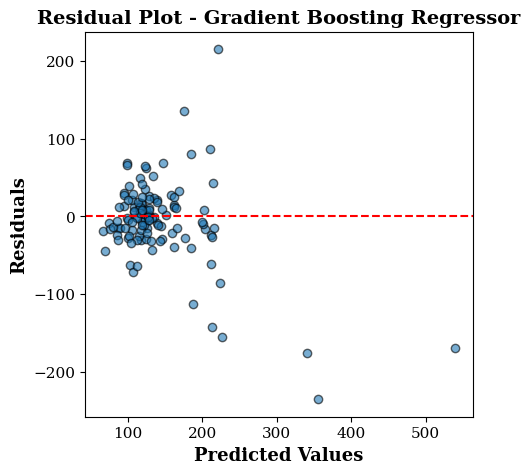


Training: SVR ...

--- Regression Metrics: SVR ---
MAE: 39.5036
MSE: 3517.4388
RMSE: 59.3080
R2 Score: 0.0458
MAPE (%): 36.2423
Adjusted R2: -0.0523
Saved: figures/Loan_Amount_SVR_actual_vs_pred.eps


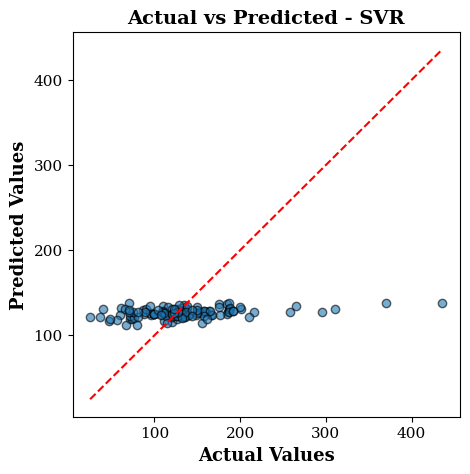

Saved: figures/Loan_Amount_SVR_residuals.eps


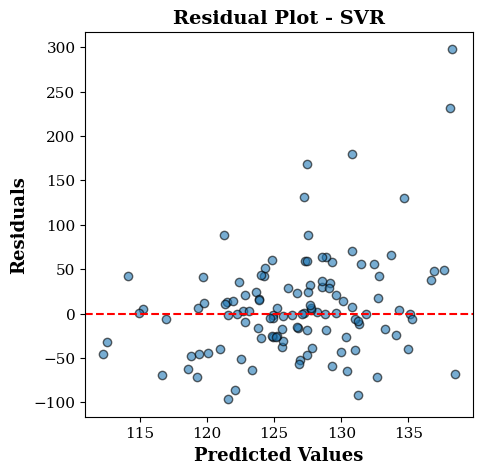


SUMMARY - Loan_Amount (regression)
                                   MAE          MSE       RMSE  R2 Score  \
Linear Regression            36.698924  3324.817540  57.661231  0.098081   
Ridge Regression             36.701540  3322.138787  57.637998  0.098807   
Lasso Regression             36.155457  3273.652387  57.215840  0.111960   
Decision Tree Regressor      48.983193  5382.092437  73.362746 -0.459994   
Random Forest Regressor      33.943846  3132.679641  55.970346  0.150202   
Gradient Boosting Regressor  33.463100  2897.245477  53.826067  0.214067   
SVR                          39.503601  3517.438798  59.307999  0.045828   

                              MAPE (%)  Adjusted R2  
Linear Regression            35.465814     0.005360  
Ridge Regression             35.478970     0.006161  
Lasso Regression             35.301396     0.020666  
Decision Tree Regressor      42.209515    -0.610087  
Random Forest Regressor      30.588694     0.062839  
Gradient Boosting Regressor  29

{'eda': {'missing':                   Missing Count  Missing %
  Gender                       13   2.195946
  Married                       2   0.337838
  Dependents                   13   2.195946
  Self_Employed                31   5.236486
  Loan_Amount_Term             14   2.364865
  Credit_History               49   8.277027,
  'outliers':                    IQR_outliers  Zscore_outliers
  ApplicantIncome              49                7
  CoapplicantIncome            18                6
  Loan_Amount_Term             85               12
  Credit_History               85                0,
  'describe':                    count unique        top freq         mean          std  \
  Gender               579      2       Male  470          NaN          NaN   
  Married              590      2        Yes  384          NaN          NaN   
  Dependents           579      4          0  334          NaN          NaN   
  Education            592      2   Graduate  465          NaN        

In [19]:
# Loan Amount Prediction - regression (LoanAmount is continuous, not a class label)
df_loan = pd.read_csv('loan_amount_prediction/train_u6lujuX_CVtuZ9i.csv')
df_loan = df_loan.drop(columns=['Loan_ID']).dropna(subset=['LoanAmount']).reset_index(drop=True)
run_ml_pipeline(df_loan, target_col='LoanAmount', task_type='regression', dataset_name='Loan_Amount')

## Email Spam - classification

EXPLORATORY DATA ANALYSIS: Email_Spam

--- Shape ---
 (5172, 3001)

--- Data types ---
 the           int64
to            int64
ect           int64
and           int64
for           int64
              ...  
military      int64
allowing      int64
ff            int64
dry           int64
Prediction    int64
Length: 3001, dtype: object

--- Summary statistics ---
              count      mean        std  min  25%  50%  75%    max
the         5172.0  6.640565  11.745009  0.0  0.0  3.0  8.0  210.0
to          5172.0  6.188128   9.534576  0.0  1.0  3.0  7.0  132.0
ect         5172.0  5.143852  14.101142  1.0  1.0  1.0  4.0  344.0
and         5172.0  3.075599   6.045970  0.0  0.0  1.0  3.0   89.0
for         5172.0  3.124710   4.680522  0.0  1.0  2.0  4.0   47.0
...            ...       ...        ...  ...  ...  ...  ...    ...
military    5172.0  0.006574   0.138908  0.0  0.0  0.0  0.0    4.0
allowing    5172.0  0.004060   0.072145  0.0  0.0  0.0  0.0    3.0
ff          5172.0  0.914733   2

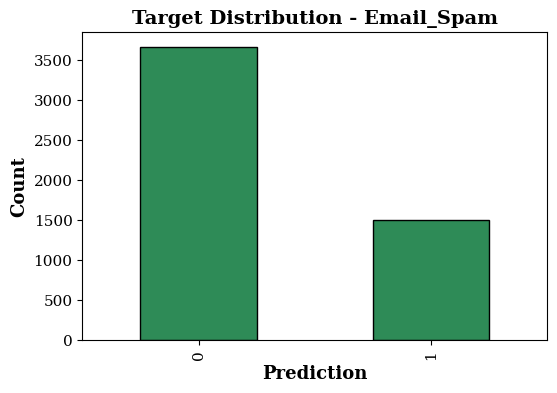


Selected top 300 features: ['of', 'you', 'hou', 'in', 'enron', 'i', 'with', 'your', 's', 'it', 'gas', 'deal', 'meter', 'hpl', 'please', 're', 'our', 'd', 'know', 'forwarded', 'mmbtu', 'do', 'daren', 'so', 'xls', 'farmer', 'attached', 'us', 'one', 'only', 'http', 'volume', 'more', 'sitara', 'texas', 'nom', 'questions', 'www', 'volumes', 'pm', 'here', 'b', 'flow', 'following', 'p', 'over', 'inc', 'nomination', 'its', 'thanks', 'per', 'forward', 'free', 'daily', 'use', 'r', 'statements', 'go', 'x', 'within', 'than', 'off', 'f', 'stock', 'actuals', 'u', 'money', 'looking', 'iv', 'noms', 'future', 'best', 'many', 'such', 'info', 'subject', 've', 'g', 'investment', 'computron', 'most', 'offer', 'prices', 'securities', 'able', 'id', 'site', 'reply', 'news', 'put', 'save', 'v', 'nd', 'bob', 'via', 'world', 'hanks', 'special', 'without', 'software', 'st', 'own', 'companies', 'advice', 'form', 'security', 'xp', 'top', 'results', 'stocks', 'dollars', 'follow', 'past', 'stop', 'move', 'y', 'visit

{'eda': {'missing': Empty DataFrame
  Columns: [Missing Count, Missing %]
  Index: [],
  'outliers':                 IQR_outliers  Zscore_outliers
  the                      400              109
  to                       471              113
  ect                      665               67
  and                      555              120
  for                      450              113
  ...                      ...              ...
  infrastructure            13               13
  military                  17               17
  allowing                  19               19
  ff                       528               45
  dry                       32               32
  
  [3000 rows x 2 columns],
  'describe':              count      mean        std  min  25%  50%  75%    max
  the         5172.0  6.640565  11.745009  0.0  0.0  3.0  8.0  210.0
  to          5172.0  6.188128   9.534576  0.0  1.0  3.0  7.0  132.0
  ect         5172.0  5.143852  14.101142  1.0  1.0  1.0  4.0  344.0
  and  

In [20]:
# Email Spam - classification (3000 word-count features -> select top 300)
df_spam = pd.read_csv('email_classification/emails.csv').drop(columns=['Email No.'])
run_ml_pipeline(df_spam, target_col='Prediction', task_type='classification',
                 dataset_name='Email_Spam', k_best=300)